\begin{titlepage}

\begin{center}

\vspace*{2cm}

{\Large Universidade de Brasília}\\[0.3cm]
{\large Departamento de Engenharia Elétrica}\\[2cm]

{\Large \textbf{
Comunicações Móveis - PPGEE UnB
}}\\[1.5cm]

{\Huge \textbf{Trabalho 3 - Cell Free Massive MIMO}}\\[2cm]

{\large
Professor: Higo Thaian Pereira da Silva\\[0.3cm]
Aluno: Artur Padovesi Piratelli\\[0.3cm]
Matrícula: 261101032
}

\vfill

{\large Brasília}\\
{\large 2026}

\end{center}

\end{titlepage}

# Introdução

As redes **Cell-Free Massive MIMO** representam uma evolução das arquiteturas celulares tradicionais ao substituir estações rádio-base de alta potência por um grande número de Pontos de Acesso (Access Points - APs) distribuídos geograficamente e conectados a uma Unidade Central de Processamento (Central Processing Unit - CPU). Nessa arquitetura, todos os APs cooperam para atender simultaneamente todos os Equipamentos de Usuário (User Equipments - UEs), compartilhando os mesmos recursos de tempo e frequência.

Neste notebook é implementado um simulador de uma rede Cell-Free Massive MIMO baseado no modelo proposto por Ngo *et al.* e nos slides sobre Massive Mimo da disciplina de Comunicações Móveis do professor Higo Thaian. O objetivo é avaliar o desempenho do sistema por meio de simulações de Monte Carlo, considerando tanto a variabilidade da geometria da rede quanto as diferentes realizações do canal de pequena escala.

O modelo implementado considera:

- desvanecimento em larga escala utilizando o modelo **Close-In Free-Space (CI)** com sombreamento log-normal;
- desvanecimento Rayleigh para representar o canal de pequena escala;
- estimação de canal por **MMSE** utilizando pilotos ortogonais;
- transmissão em downlink utilizando **_Conjugate Beamforming_**.

Duas métricas principais de desempenho são analisadas:

- **SINR (Signal-to-Interference-plus-Noise Ratio)**;
- **Taxa alcançável (Achievable Rate)**, obtida a partir da capacidade de Shannon.

Para cada geometria da rede são geradas diversas realizações independentes do canal de pequena escala, mantendo fixas as posições dos APs e UEs. Essa separação permite avaliar isoladamente os efeitos do desvanecimento rápido e da propagação em larga escala.

Ao longo deste notebook serão investigados os impactos de diferentes parâmetros do sistema sobre o desempenho da rede, por meio da comparação das distribuições empíricas (ECDFs) da SINR e da taxa alcançável. Os parâmetros analisados neste documento são:

- número de APs;
- densidade da implantação da rede;
- número de usuários;
- comprimento da sequência de pilotos;
- potência de transmissão.

Sempre que não explicitado o contrário, será utilizada uma configuração de referência (_baseline_), a partir da qual cada parâmetro será variado individualmente para avaliar sua influência sobre o desempenho do sistema. O _baseline_ pode ser visto na tabela 1.

**Tabela 1 – Parâmetros utilizados na configuração de referência.**

| Parâmetro | Valor |
|-----------|------:|
| Frequência da portadora ($f_c$) | 3 GHz |
| Largura de banda ($B$) | 20 MHz |
| Potência de transmissão dos APs ($P_d$) | 200 mW |
| Potência de transmissão dos pilotos ($P_p$) | 100 mW |
| Figura de ruído | 9 dB |
| Temperatura de ruído | 296,15 K |
| Área de simulação | 1000 $\times$ 1000 m |
| Altura dos APs | 15 m |
| Altura dos UEs | 1,65 m |
| Número de APs ($M$) | 100 |
| Número de UEs ($K$) | 10 |
| Comprimento da sequência de pilotos ($\tau_\text{cf}$) | 10 |

# Implementação

Em geral, a implementação segue exatamente o modelo proposto pelo professor Higo Thaian, com adoções do modelo original quando adequado. Estes casos foram:
- $\Omega$ é ganho de larga escala do canal. As equações (29), (30) e (32) dos slides não considera a conversão de perda de percurso para ganho de percurso;
- na equação (36) do documento $\gamma$ é proporcional a $\sqrt{P_d}$, enquanto no modelo original de Ngo, na equação (8), $\gamma$ é proporcional a $\sqrt{P_p}$. A modelagem original foi considerada;
- A equação (21) do documento mostra uma versão de SINR diferente do artigo original. A versão original é utilizada no artigo de Ngo, na equação (26), e pode ser escrita da seguinte maneira, seguindo a notação do documento do professor:

\begin{equation}
\mathrm{SINR}_k =
\frac{
P_d
\left|
\sum_{m=1}^{M}
\sqrt{\eta_{m,k}}\,
g_{m,k}\,
\hat{g}_{m,k}^{*}
\right|^{2}
}{
P_d
\sum_{k' \neq k}^{K}
\left|
\sum_{m=1}^{M}
\sqrt{\eta_{m,k'}}\,
g_{m,k}\,
\hat{g}_{m,k'}^{*}
\right|^{2}
+\sigma_w^{2}
}.
\end{equation}

# Resultados

In [1]:
from cell_free import CellFree, plot_scenarios
import matplotlib.pyplot as plt
import numpy as np

basic_params = {
    "fc": 3e9, "bw": 20e6,
    "noise_fig_db": 9, "noise_temperature": 296.15,
    "area_dimensions": (1e3, 1e3),
    "ap_h": 15, "ue_h": 1.65,
    "num_ue": 10, "tau_cf": 10,
    "num_ap": 100,
    "pilot_pow_db": 10 * np.log10(0.1),
    "downlink_pow_db": 10 * np.log10(0.2),
}

## Cenário 1 - Variando o Número de APs


**Tabela 2 – Parâmetros utilizados no Cenário 1.**

| Parâmetro | Valor |
|-----------|------:|
| Número de APs ($M$) | 100, 150, 200 |

100%|██████████| 300/300 [00:06<00:00, 43.58it/s]


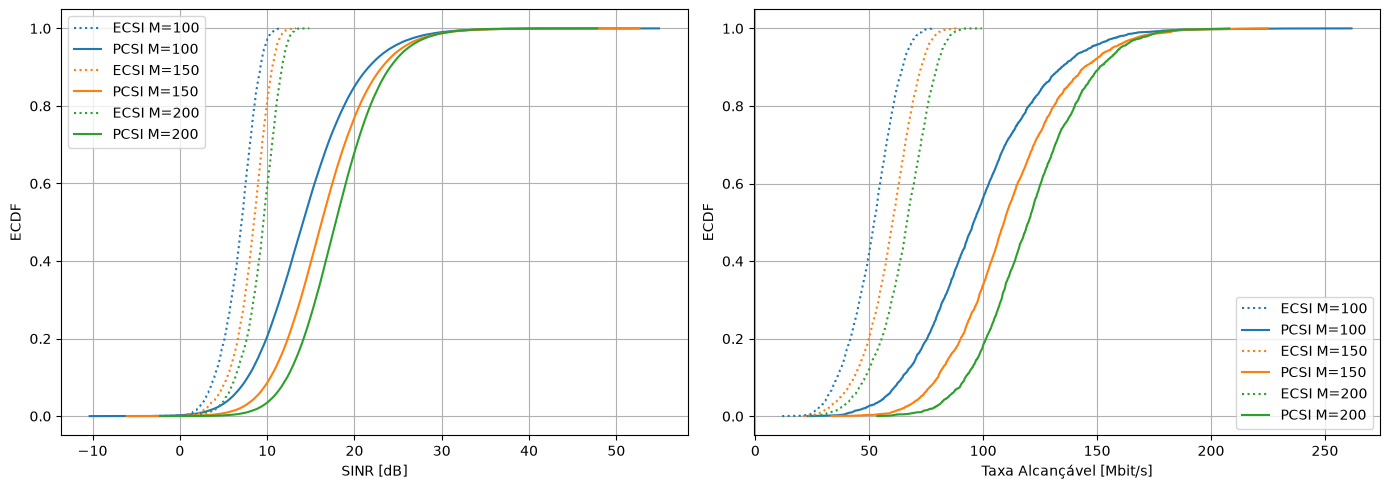

In [2]:
all_params = [
    {**basic_params, 'num_ap': x} for x in [100, 150, 200]
]
results = []
for par in all_params:
    cell_free_sim = CellFree(**par)
    rng = np.random.default_rng(12331)
    res = cell_free_sim.simulate(rng, 300, 100)
    label = f"M={par['num_ap']}"
    results.append((label, res))

plot_scenarios(results)

plt.show()

Como esperado, conforme $M$ aumenta, a potência disponível para cada usuário aumenta, levando a uma melhora nas SINR e taxa alcançável.

## Cenário 2 - Variando Número de Usuários

Foram utilizados diferentes números de usuários $K \in \{ 10, 20, 40 \}$, mantendo sempre $\tau_\text{cf} = K$.


**Tabela 3 – Parâmetros utilizados no Cenário 2.**

| Parâmetro | Valor |
|-----------|------:|
| Número de UEs ($K$) | 10, 20, 40, 100 |

100%|██████████| 300/300 [02:48<00:00,  1.78it/s]


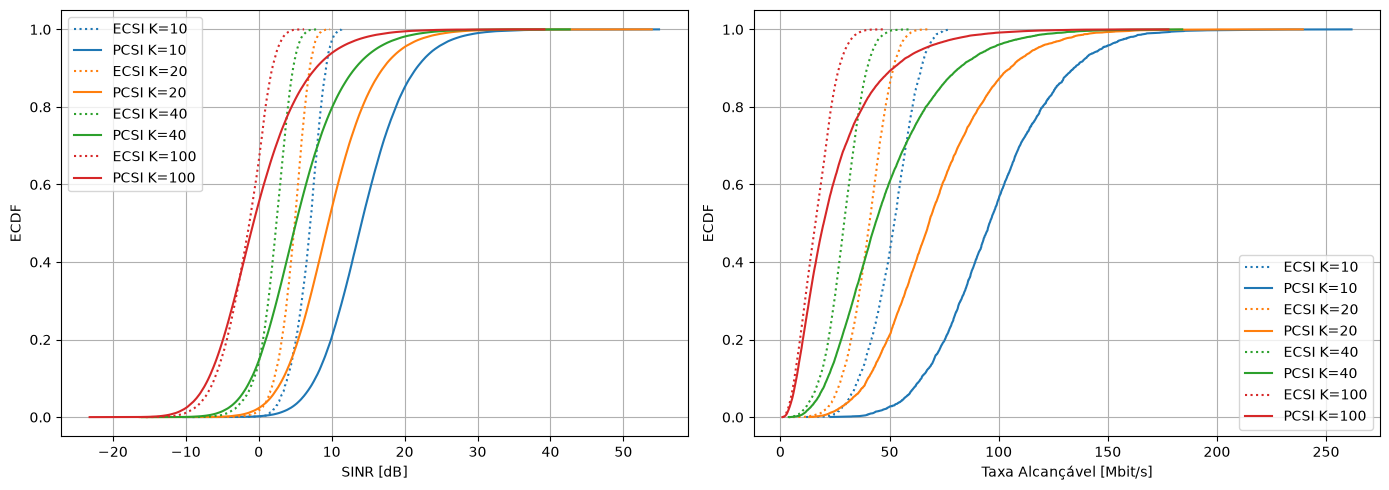

In [9]:
all_params = [
    {**basic_params, "num_ue": 10, "tau_cf": 10},
    {**basic_params, "num_ue": 20, "tau_cf": 20},
    {**basic_params, "num_ue": 40, "tau_cf": 40},
    {**basic_params, "num_ue": 100, "tau_cf": 100},
]

results = []

for par in all_params:
    cell_free_sim = CellFree(**par)
    rng = np.random.default_rng(12331)
    res = cell_free_sim.simulate(rng, 300, 100)

    label = f"K={par['num_ue']}"
    results.append((label, res))

plot_scenarios(results)
plt.show()

Mesmo que os pilotos se mantenham ortogonais, é possível notar que há uma piora considerável em SINR e taxa alcançável conforme $K$ aumenta. Além disso, a piora é mais severa para a distribuição de SINR instantânea e taxa alcançável dado CSI perfeito do que para SINR e taxa alcançável estatísticos.

No caso particular com $K=100$, percebe-se que, por 60% do tempo a taxa alcançável com CSI Perfeito não apresenta melhora significativa comparando com CSI estatística.

## Cenário 3 - Variando o Número de APs e Área de Cobertura

Com o propósito de manter a densidade aproximadamente constante, a área de cobertura é aumentada conforme $M$ aumenta.


**Tabela 4 - Parâmetros utilizados no Cenário 3.**

| Parâmetro | Valor |
|-----------|------:|
| Densidade de APs | 100 por $\text{km}^2$ |
| Número de APs ($M$) | 100, 150, 200 |
| Área de Cobertura | 1 $\times$ 1, 1.225 $\times$ 1.225, 1.414 $\times$ 1.414 $\text{km}$ |

100%|██████████| 300/300 [00:06<00:00, 47.75it/s]


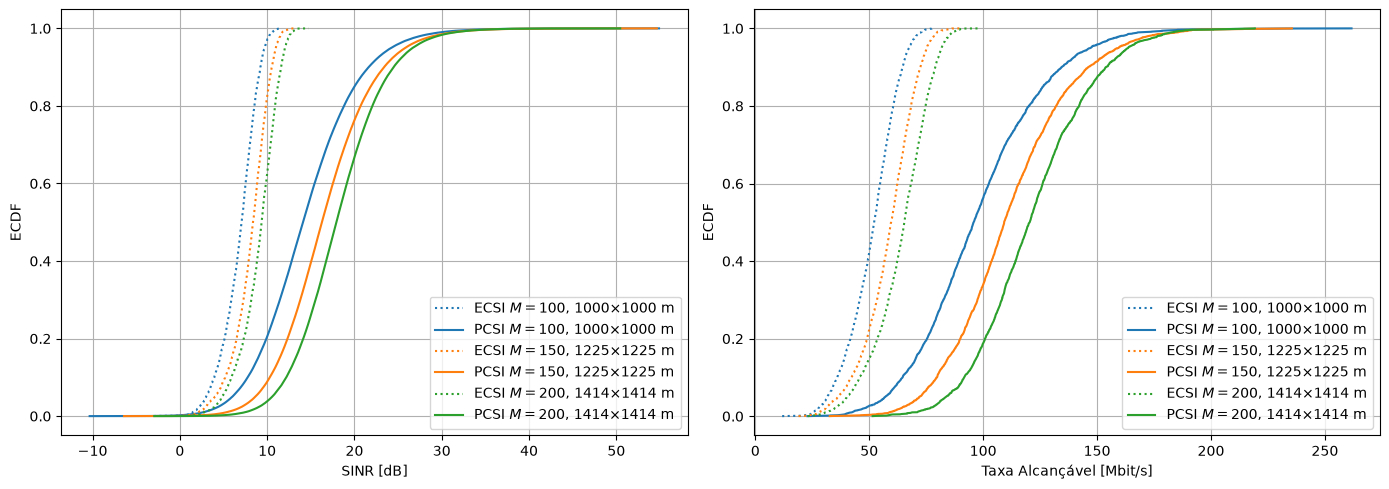

In [11]:
all_params = [
    {**basic_params, "num_ap": 100, "area_dimensions": (1000, 1000)},
    {**basic_params, "num_ap": 150, "area_dimensions": (1225, 1225)},
    {**basic_params, "num_ap": 200, "area_dimensions": (1414, 1414)},
]

results = []

for par in all_params:
    cell_free_sim = CellFree(**par)
    rng = np.random.default_rng(12331)
    res = cell_free_sim.simulate(rng, 300, 100)

    label = (
        f"$M={par['num_ap']}$, "
        f"{par['area_dimensions'][0]:.0f}×{par['area_dimensions'][1]:.0f} m"
    )
    results.append((label, res))

plot_scenarios(results)
plt.show()

Diferente do esperado intuitivamente, os resultados do Cenário 3 estão praticamente os mesmos do Cenário 1. Ou seja, um aumento no número de APs no cenário base surte um efeito muito mais significativo que a sua diluição em área.

## Cenário 4 - Variando o Número de APs e UEs

Com o propósito de manter a razão $M/K$ constante, o número de usuários aumenta com mesma proporção com que $M$ aumenta.


**Tabela 5 - Parâmetros utilizados no Cenário 4.**

| Parâmetro | Valor |
|-----------|------:|
| Razão $M/K$ | 10 |
| Número de APs ($M$) | 20, 100, 150, 200 |
| Número de UEs | 2, 10, 15, 20 |

100%|██████████| 300/300 [00:14<00:00, 20.07it/s]


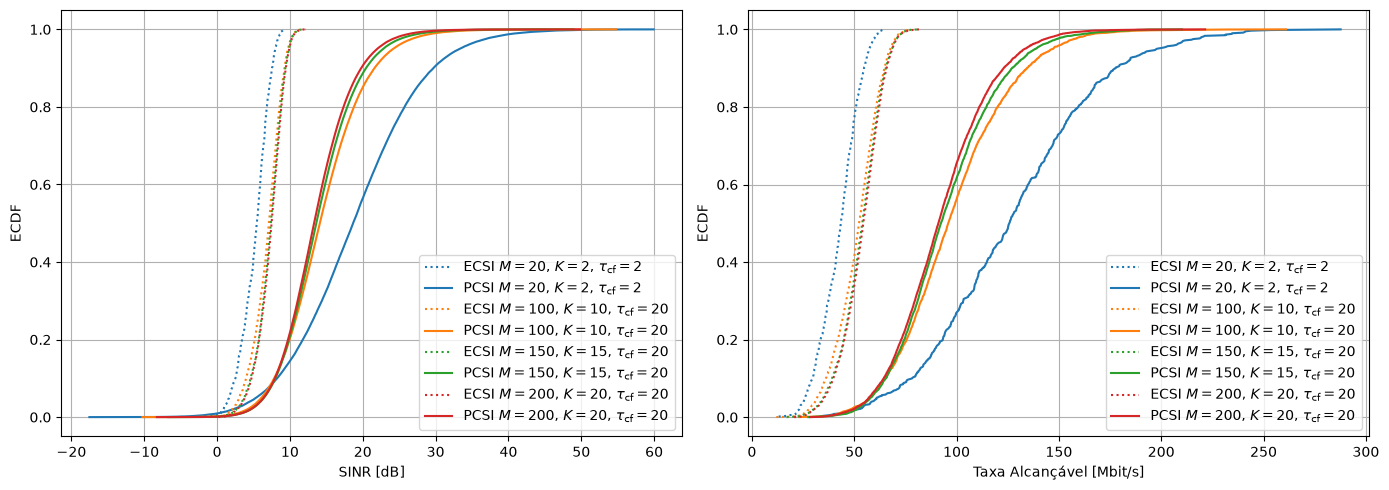

In [16]:
all_params = [
    {**basic_params, "num_ap": 20, "num_ue": 2, "tau_cf": 2},
    {**basic_params, "num_ap": 100, "num_ue": 10, "tau_cf": 20},
    {**basic_params, "num_ap": 150, "num_ue": 15, "tau_cf": 20},
    {**basic_params, "num_ap": 200, "num_ue": 20, "tau_cf": 20},
]

results = []

for par in all_params:
    cell_free_sim = CellFree(**par)
    rng = np.random.default_rng(12331)
    res = cell_free_sim.simulate(rng, 300, 100)

    label = (
        f"$M={par['num_ap']}$, "
        f"$K={par['num_ue']}$, "
        r"$\tau_\text{cf}" f"={par['tau_cf']}$"
    )
    results.append((label, res))

plot_scenarios(results)
plt.show()

Com esse caso, é possível notar que o fator mais relevante para manutenção de performance não é densidade de APs por espaço, mas sim a razão $M/K$. Para os cenários com $K \ge 10$, a performance de todos foi extremamente semelhante. Já o cenário com $K=2$ apresentou um resultado consideravelmente diferente, por mais que a razão tenha sido mantida. A taxa alcançável com conhecimento estatístico do canal apresentou ligeira piora quando comparada com os outros cenários, mas com CSI perfeita apresentou melhora considerável. A piora ocorre devido a ausência de _channel hardening_, com a presença de poucos APs, enquanto a melhora ocorre devido à presença de baixíssima interferência no regime instantâneo após considerar inclusive as perdas de percurso.

## Cenário 5 - Variando a Potência de Transmissão em Downlink

Neste cenário, avalia-se a influência da potência de transmissão em downlink ($P_d$) sobre o desempenho do sistema Cell-Free Massive MIMO. A potência disponível para transmissão afeta diretamente a potência do sinal recebido pelos usuários e, consequentemente, a relação sinal-interferência-ruído (SINR). Entretanto, como a interferência entre usuários também é proporcional à potência de transmissão, espera-se que o aumento de $P_d$ resulte em ganhos significativos apenas quando o sistema opera em regime limitado por ruído. Em regimes limitados por interferência, o benefício tende a diminuir, uma vez que tanto o sinal desejado quanto a interferência aumentam na mesma proporção.

Para essa análise, são considerados quatro níveis de potência de transmissão em downlink, variando de 0,1 mW a 100 mW, mantendo-se inalterados os demais parâmetros do cenário base.

**Tabela 6 - Parâmetros utilizados no Cenário 5.**

| Parâmetro | Valor |
|-----------|------:|
| Potência de transmissão em downlink ($P_d$) | 0,1 mW, 1 mW, 10 mW, 100 mW |

100%|██████████| 300/300 [00:03<00:00, 81.54it/s]


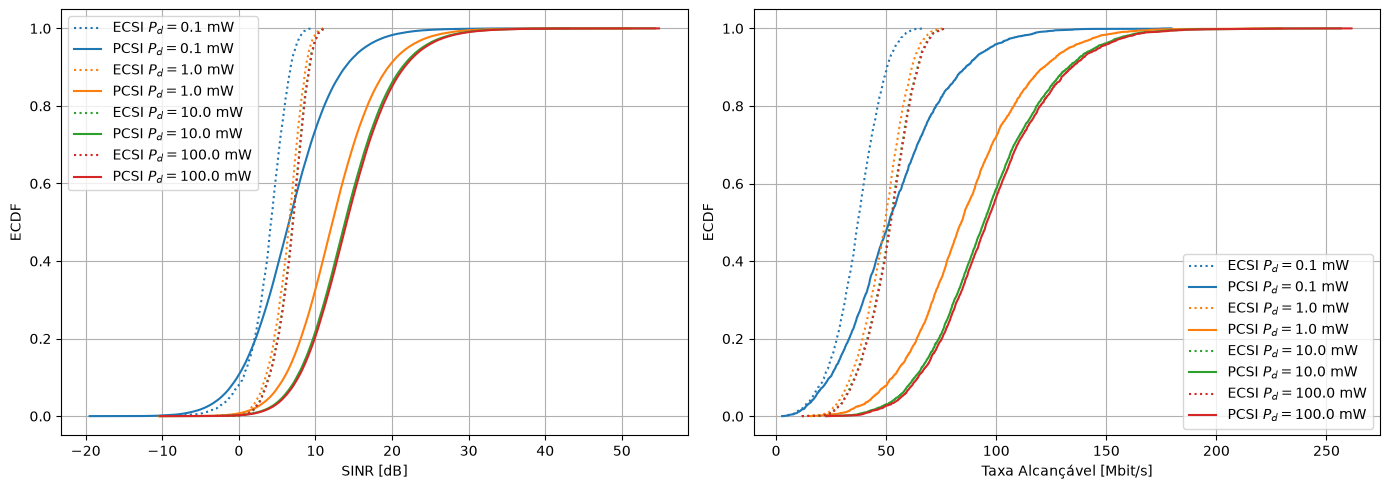

In [14]:
all_params = [
    {**basic_params, "downlink_pow_db": 10*np.log10(0.0001)},
    {**basic_params, "downlink_pow_db": 10*np.log10(0.001)},
    {**basic_params, "downlink_pow_db": 10*np.log10(0.01)},
    {**basic_params, "downlink_pow_db": 10*np.log10(0.1)},
]

results = []

for par in all_params:
    cell_free_sim = CellFree(**par)
    rng = np.random.default_rng(12331)
    res = cell_free_sim.simulate(rng, 300, 100)

    power = 10**(par["downlink_pow_db"]/10)*1000
    label = f"$P_d={power}$ mW"

    results.append((label, res))

plot_scenarios(results)
plt.show()

Os resultados demonstram que, a partir de certa potência, aumentar a potência de transmissão de dados não auxilia na melhora de SINR e de taxa alcançável. Isso é esperado pois, tanto o sinal desejado quanto a interferência são multiplicados por um mesmo escalar derivado dessa potência. O que ocorre é que, quando $P_d >> \sigma_w$, o canal passa a não depender do ruído, e aumentar essa potência não surte mais efeito.

## Cenário 6 - Variando o Comprimento da Sequência de Pilotos

Neste cenário, analisa-se a influência do comprimento da sequência de pilotos ($\tau_\text{cf}$) na qualidade da estimação do canal e, consequentemente, no desempenho do sistema. Como a energia total utilizada na estimação é proporcional ao produto $\tau_\text{cf}P_p$, espera-se que o aumento do comprimento da sequência proporcione melhorias apenas enquanto a estimação estiver limitada pelo ruído. Após determinado ponto, a qualidade da estimação tende a saturar, tornando pouco significativo o aumento adicional de $\tau_\text{cf}$.

Para essa análise, são considerados três comprimentos de sequência de pilotos, mantendo-se constantes todos os demais parâmetros do cenário base.

**Tabela 7 - Parâmetros utilizados no Cenário 6.**

| Parâmetro | Valor |
|-----------|------:|
| Comprimento da sequência de pilotos ($\tau_\text{cf}$) | 10, 50, 100 |

100%|██████████| 300/300 [00:03<00:00, 82.87it/s]


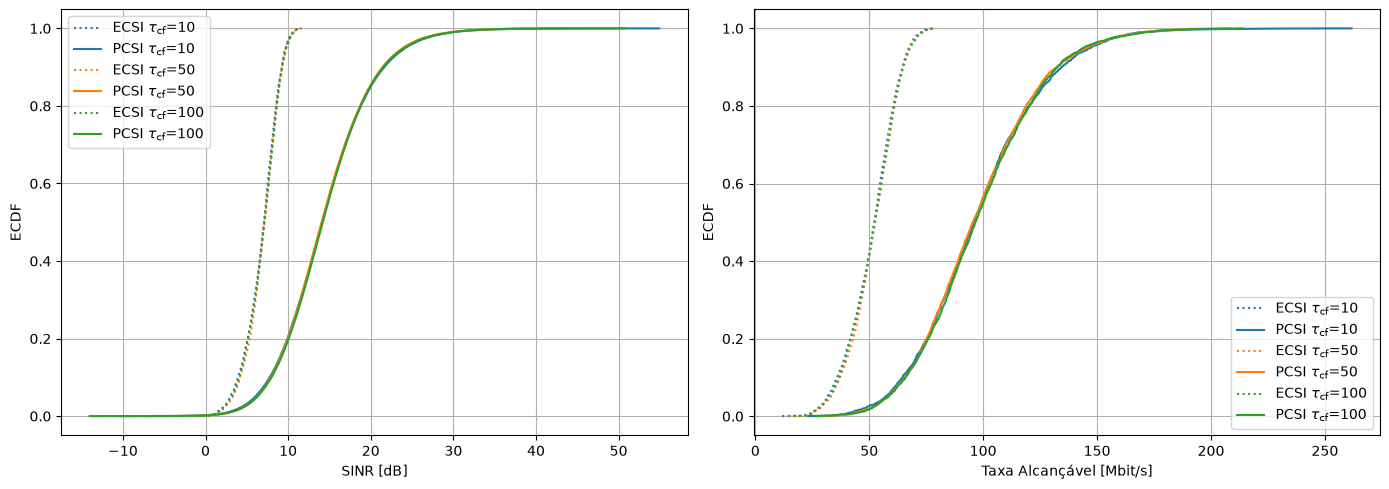

In [17]:
all_params = [
    {**basic_params, "tau_cf": 10},
    {**basic_params, "tau_cf": 50},
    {**basic_params, "tau_cf": 100},
]

results = []

for i, par in enumerate(all_params):
    cell_free_sim = CellFree(**par)
    rng = np.random.default_rng(12331 + i)
    res = cell_free_sim.simulate(rng, 300, 100)

    label = rf"$\tau_\text{{cf}}$={par['tau_cf']}"
    results.append((label, res))

plot_scenarios(results)
plt.show()

É interessante que, alterando \tau_\text{cf} no cenário original, todas as curvas se sobrepoem perfeitamente. 

Considerando a estimação MMSE do canal, o sinal piloto recebido e projetado para o usuário $k$ é dado por

\begin{equation}
\check{y}_{m,k}
=
\sqrt{\tau_{\mathrm{cf}} P_p}\, g_{m,k}
+
w_{m,k},
\end{equation}

onde $w_{m,k}$ representa o ruído complexo gaussiano.

A estimativa do canal é obtida por

\begin{equation}
\hat{g}_{m,k}
=
c_{m,k}\,\check{y}_{m,k},
\end{equation}

onde, considerando que os pilotos são ortogonais,

\begin{equation}
c_{m,k}
=
\frac{\sqrt{\tau_{\mathrm{cf}}P_p}\,\Omega_{m,k}}
{\tau_{\mathrm{cf}}P_p\Omega_{m,k}+\sigma_w^2}.
\end{equation}

A variância da estimativa é

\begin{equation}
\gamma_{m,k}
=
\mathbb{E}\!\left\{\left|\hat g_{m,k}\right|^2\right\}
=
\sqrt{\tau_{\mathrm{cf}}P_p}\,\Omega_{m,k}\,c_{m,k},
\end{equation}

ou, substituindo a expressão de $c_{m,k}$,

\begin{equation}
\gamma_{m,k}
=
\frac{\tau_{\mathrm{cf}}P_p\,\Omega_{m,k}^{2}}
{\tau_{\mathrm{cf}}P_p\Omega_{m,k}+\sigma_w^2}.
\end{equation}

Observa-se que, quando

\begin{equation}
\tau_{\mathrm{cf}}P_p\Omega_{m,k}
\gg
\sigma_w^2,
\end{equation}

tem-se

\begin{equation}
\gamma_{m,k}
\approx
\Omega_{m,k},
\end{equation}

ou seja, a qualidade da estimação torna-se praticamente limitada apenas pelo ganho de larga escala do canal. Nesse regime, aumentar o comprimento da sequência de pilotos não produz melhorias perceptíveis na estimação e, consequentemente, na SINR e na taxa alcançável.

## Cenário 7 - Variando a Potência e o Comprimento da Sequência de Pilotos

Neste cenário, busca-se analisar conjuntamente a influência da potência de transmissão dos pilotos ($P_p$) e do comprimento da sequência de pilotos ($\tau_\text{cf}$) sobre o desempenho do sistema. Conforme discutido anteriormente, o aumento de $\tau_\text{cf}$ tende a melhorar a qualidade da estimação do canal apenas enquanto a energia total dedicada aos pilotos é insuficiente para que a estimação atinja seu regime de saturação.

Para investigar esse comportamento, são considerados dois valores de potência de transmissão dos pilotos, $P_p \in \{0.1,\;1\}$ mW, e dois comprimentos de sequência de pilotos, $\tau_\text{cf} \in \{10,\;100\}$. Dessa forma, é possível avaliar se o aumento do comprimento da sequência continua proporcionando ganhos quando a potência dos pilotos é reduzida.

**Tabela 8 - Parâmetros utilizados no Cenário 7.**

| Parâmetro | Valor |
|-----------|------:|
| Comprimento da sequência de pilotos ($\tau_\text{cf}$) | 10, 100 |
| Potência dos pilotos ($P_p$) | 0,1 mW, 1 mW |

100%|██████████| 300/300 [00:03<00:00, 81.28it/s]


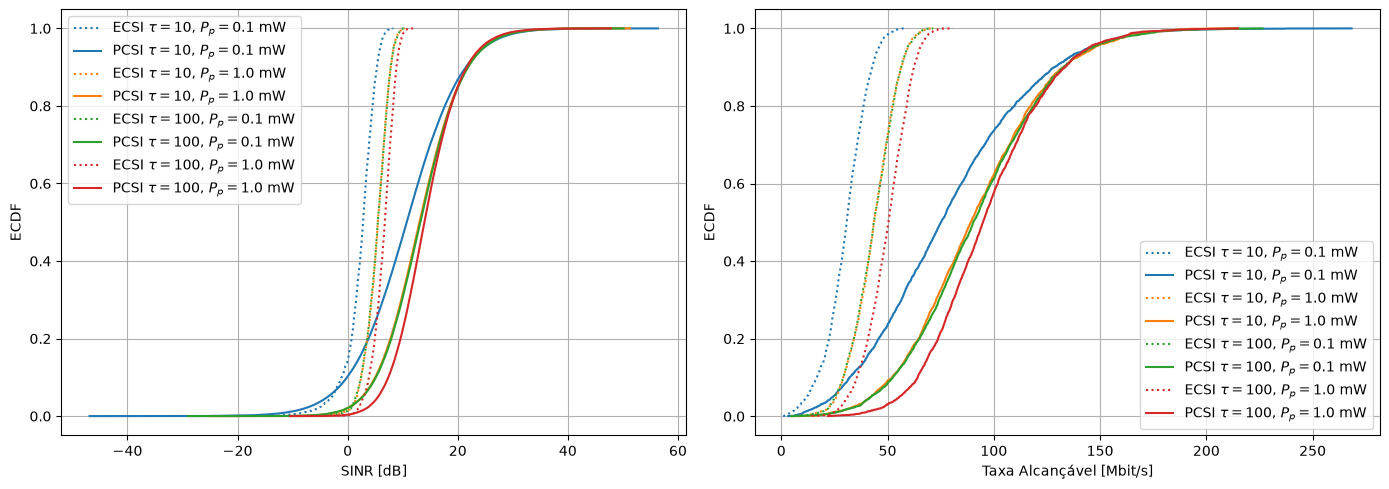

In [ ]:
all_params = [
    {**basic_params,
     "tau_cf": 10,
     "pilot_pow_db": 10*np.log10(0.0001)},

    {**basic_params,
     "tau_cf": 10,
     "pilot_pow_db": 10*np.log10(0.001)},

    {**basic_params,
     "tau_cf": 100,
     "pilot_pow_db": 10*np.log10(0.0001)},

    {**basic_params,
     "tau_cf": 100,
     "pilot_pow_db": 10*np.log10(0.001)},
]

results = []

for i, par in enumerate(all_params):
    cell_free_sim = CellFree(**par)
    rng = np.random.default_rng(12331+i)
    res = cell_free_sim.simulate(rng, 300, 100)

    power = 10**(par["pilot_pow_db"]/10)*1000
    label = rf"$\tau_\text{{cf}}={par['tau_cf']}$, $P_p={power}$ mW"

    results.append((label, res))

plot_scenarios(results)
plt.show()

Como pode ser visto nas equações de estimação de canal, a sua qualidade depende da energia do piloto até um certo limiar, onde $\tau_\text{cf} P_p >> \sigma_w^2$. Além disso, os casos com $P_p=1$, $\tau_\text{cf} = 10$ e $P_p=0.1$, $\tau_\text{cf} = 100$ possuem mesma energia de piloto $\tau_\text{cf} P_p$, e portanto suas curvas de SINR e taxa alcançável estão sobrepostas.

# Conclusões

Os resultados mostram que o desempenho da rede depende muito mais da razão M/K do que da densidade de APs por área. Isso ficou claro ao comparar os Cenários 1 e 3: aumentar M mantendo a densidade constante (Cenário 3) deu praticamente o mesmo resultado que aumentar M mantendo a área fixa (Cenário 1), enquanto no Cenário 4, cenários com M/K = 10 tiveram desempenho semelhante entre si, mesmo variando M e K bastante — exceto pelo caso $M=20$, $K=2$, que fugiu do padrão por falta de channel hardening.

Aumentar o número de usuários (Cenário 2) piora SINR e taxa alcançável mesmo com pilotos ortogonais, e essa piora é mais forte no regime instantâneo (CSI perfeito) do que no estatístico, o que faz sentido já que a interferência entre usuários cresce com $K$.

Já potência de downlink (Cenário 5) e energia de piloto (Cenários 6 e 7) mostraram o comportamento esperado de saturação: depois de um certo ponto, aumentar P_d não ajuda porque sinal e interferência crescem juntos, e aumentar $\tau_\text{cf}$ ou $P_p$ não ajuda porque a estimativa de canal já está limitada pelo ganho de larga escala $\Omega$. O Cenário 7 deixou isso bem explícito, além de permitir notar outra observação: o que importa é o produto $\tau_\text{cf} P_p$, não os dois separadamente.
